In [91]:
# Install graph-cut library
!pip install PyMaxflow

In [92]:
# Clone your GitHub repository
!git clone https://github.com/Priya-Kumari-Chourasia/cv_a2_data.git

fatal: destination path 'cv_a2_data' already exists and is not an empty directory.


In [93]:
import os

# Repository is cloned in /content in Google Colab
repo_dir = "/content/cv_a2_data"
base_dir = repo_dir

# Folder for saving output images
output_dir = os.path.join(repo_dir, "outputs")
os.makedirs(output_dir, exist_ok=True)

print("Repo contents:", os.listdir(repo_dir))
print("Dataset folder contents:", os.listdir(base_dir))

Repo contents: ['nature_sc.png', 'outputs', 'object_sc1.png', 'medical.jpg', 'object1.jpg', '.git', 'image4.jpg', 'medical_sc.png']
Dataset folder contents: ['nature_sc.png', 'outputs', 'object_sc1.png', 'medical.jpg', 'object1.jpg', '.git', 'image4.jpg', 'medical_sc.png']


# 1. Import libraries

In [94]:
# =========================
# 1. Import libraries
# =========================
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import maxflow

In [95]:
# -------------------------
# Define dataset
# -------------------------
# Each dictionary contains:
# - name      : label used in display/output
# - img       : original image path
# - scribble  : corresponding scribble image path

dataset = [
    {"name": "Image 1", "img": os.path.join(base_dir, "object1.jpg"), "scribble": os.path.join(base_dir, "object_sc1.png")},
    {"name": "Image 2", "img": os.path.join(base_dir, "image4.jpg"),  "scribble": os.path.join(base_dir, "nature_sc.png")},
    {"name": "Image 3", "img": os.path.join(base_dir, "medical.jpg"), "scribble": os.path.join(base_dir, "medical_sc.png")},
]


# 2. Read an image in RGB format


In [96]:

def read_rgb(path):
  """
    Reads an image from disk and converts it from BGR to RGB.

    Parameters:
        path (str): Path to image file.

    Returns:
        np.ndarray: RGB image.

    Raises:
        FileNotFoundError: If image cannot be read.
    """
  img = cv2.imread(path)
  if img is None:
      raise FileNotFoundError(f"Could not read file: {path}")
  return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 3. Extract foreground/background seeds from scribble image

In [97]:
def extract_seeds_from_overlay(original, scribble):
    """
    Extracts user scribbles from an image where annotations are drawn
    over the original image.

    Red strokes  -> foreground seeds
    Blue strokes -> background seeds
    """

    # absolute difference between original and scribble image
    diff = np.abs(scribble.astype(np.int16) - original.astype(np.int16))
    changed = np.sum(diff, axis=2) > 60

    # red = foreground
    fg = changed & (scribble[:, :, 0] > 140) & (scribble[:, :, 1] < 130) & (scribble[:, :, 2] < 130)

    # blue = background
    bg = changed & (scribble[:, :, 2] > 140) & (scribble[:, :, 0] < 130) & (scribble[:, :, 1] < 130)

    return fg, bg

# 4. Histogram-based foreground/background modeling

In [98]:
def build_histogram_model(pixels, bins=16):
    """
    Build a 3D RGB histogram model for a set of pixels.

    Laplace smoothing (+1) is applied to avoid zero probabilities.

    Parameters:
        pixels (np.ndarray): Pixel values of shape (N, 3).
        bins (int): Number of bins per color channel.

    Returns:
        np.ndarray: Normalized 3D histogram.
    """
    hist, _ = np.histogramdd(
        pixels,
        bins=(bins, bins, bins),
        range=((0, 256), (0, 256), (0, 256))
    )

    # Laplace smoothing
    hist = hist + 1.0

    # Normalize to probability distribution
    hist = hist / np.sum(hist)
    return hist

In [99]:
def get_histogram_probabilities(img, hist, bins=16):
    """
    Maps each image pixel to its histogram probability.
    This gives P(pixel | foreground) or P(pixel | background).
    """
    bin_size = 256 // bins
    inds = np.floor(img / bin_size).astype(int)
    inds = np.clip(inds, 0, bins - 1)
    probs = hist[inds[:, :, 0], inds[:, :, 1], inds[:, :, 2]]
    return probs

# 5. Compute beta for smoothness term

In [100]:
def compute_beta(image):
    """
    Computes beta used in the smoothness/pairwise term:
    exp(-beta * ||Ip - Iq||^2)
    """
    image = image.astype(np.float32)
    h, w, _ = image.shape
    diffs = []

    for y in range(h):
        for x in range(w):
            if x + 1 < w:
                diffs.append(np.sum((image[y, x] - image[y, x + 1]) ** 2))
            if y + 1 < h:
                diffs.append(np.sum((image[y, x] - image[y + 1, x]) ** 2))

    diffs = np.array(diffs, dtype=np.float32)
    beta = 1.0 / (2.0 * np.mean(diffs) + 1e-8)
    return beta

# 6. Graph construction + min-cut / max-flow

In [101]:
def graph_cut_segmentation(img, Df, Db, lam=50):
    """
    Constructs the graph and runs max-flow/min-cut.

    Each pixel is a node.
    Source terminal = foreground
    Sink terminal   = background

    Unary costs:
        Df = cost of assigning pixel to foreground
        Db = cost of assigning pixel to background

    Pairwise costs:
        encourage neighboring pixels to have similar labels
    """
    h, w, _ = img.shape
    g = maxflow.Graph[float]()
    nodes = g.add_grid_nodes((h, w))

    # Terminal edges (unary costs)
    for y in range(h):
        for x in range(w):
            g.add_tedge(nodes[y, x], Db[y, x], Df[y, x])

    beta = compute_beta(img)
    img_f = img.astype(np.float32)

    # 8-neighborhood: right, down, down-right, down-left
    for y in range(h):
        for x in range(w):
            # Right neighbor
            if x + 1 < w:
                diff = np.sum((img_f[y, x] - img_f[y, x+1]) ** 2)
                w_right = lam * np.exp(-beta * diff)
                g.add_edge(nodes[y, x], nodes[y, x+1], w_right, w_right)

            # Down neighbor
            if y + 1 < h:
                diff = np.sum((img_f[y, x] - img_f[y+1, x]) ** 2)
                w_down = lam * np.exp(-beta * diff)
                g.add_edge(nodes[y, x], nodes[y+1, x], w_down, w_down)

            # Down-right diagonal
            if x + 1 < w and y + 1 < h:
                diff = np.sum((img_f[y, x] - img_f[y+1, x+1]) ** 2)
                w_diag1 = (lam / np.sqrt(2)) * np.exp(-beta * diff)
                g.add_edge(nodes[y, x], nodes[y+1, x+1], w_diag1, w_diag1)

            # Down-left diagonal
            if x - 1 >= 0 and y + 1 < h:
                diff = np.sum((img_f[y, x] - img_f[y+1, x-1]) ** 2)
                w_diag2 = (lam / np.sqrt(2)) * np.exp(-beta * diff)
                g.add_edge(nodes[y, x], nodes[y+1, x-1], w_diag2, w_diag2)

    # Solve maxflow / mincut
    g.maxflow()

    # Extract final binary segmentation
    mask = np.zeros((h, w), dtype=np.uint8)
    for y in range(h):
        for x in range(w):
            mask[y, x] = g.get_segment(nodes[y, x])

    return mask

# 7. Iterative optimization

In [102]:
def iterative_graph_cut(img, fg, bg, bins=16, lam=50, num_iters=3):
    """
    Refines segmentation iteratively:
    1. Build FG/BG histogram models from current seeds
    2. Compute unary costs
    3. Run graph cut
    4. Update FG/BG regions using current mask
    """
    current_fg = fg.copy()
    current_bg = bg.copy()
    all_masks = []

    for i in range(num_iters):
        fg_pixels = img[current_fg]
        bg_pixels = img[current_bg]

        fg_hist = build_histogram_model(fg_pixels, bins=bins)
        bg_hist = build_histogram_model(bg_pixels, bins=bins)

        P_fg = get_histogram_probabilities(img, fg_hist, bins=bins)
        P_bg = get_histogram_probabilities(img, bg_hist, bins=bins)

        # Unary costs = negative log-likelihood
        Df = -np.log(P_fg + 1e-8)
        Db = -np.log(P_bg + 1e-8)

        # Hard constraints for scribbles
        INF = 1e6
        Df[fg] = 0
        Db[fg] = INF
        Df[bg] = INF
        Db[bg] = 0

        raw_mask = graph_cut_segmentation(img, Df, Db, lam=lam)

        # Convert PyMaxflow output to foreground mask
        final_mask = (1 - raw_mask).astype(bool)

        all_masks.append(final_mask.copy())

        # Update current FG/BG for next iteration
        current_fg = final_mask | fg
        current_bg = (~final_mask) | bg

        print(f"  Iteration {i+1} done")

    return all_masks, final_mask

# 8. Manual morphology    (opening and closing)

In [103]:
def manual_erosion(binary_mask, kernel):
    """
    Erosion: pixel stays foreground only if all kernel-covered pixels are foreground.
    Used to remove small white noise.
    """
    h, w = binary_mask.shape
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2

    padded = np.pad(binary_mask, ((ph, ph), (pw, pw)), mode='constant', constant_values=0)
    out = np.zeros_like(binary_mask)

    for y in range(h):
        for x in range(w):
            region = padded[y:y+kh, x:x+kw]

            # Erosion: all kernel-1 positions must match foreground
            if np.all(region[kernel == 1] == 255):
                out[y, x] = 255
            else:
                out[y, x] = 0

    return out

In [104]:
def manual_dilation(binary_mask, kernel):
    """
    Dilation: pixel becomes foreground if any kernel-covered pixel is foreground.
    Used to grow regions and fill small gaps.
    """
    h, w = binary_mask.shape
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2

    padded = np.pad(binary_mask, ((ph, ph), (pw, pw)), mode='constant', constant_values=0)
    out = np.zeros_like(binary_mask)

    for y in range(h):
        for x in range(w):
            region = padded[y:y+kh, x:x+kw]

            # Dilation: if any kernel-1 position overlaps foreground
            if np.any(region[kernel == 1] == 255):
                out[y, x] = 255
            else:
                out[y, x] = 0

    return out

In [105]:
def manual_opening(binary_mask, kernel):
    """Opening = erosion followed by dilation."""
    eroded = manual_erosion(binary_mask, kernel)
    opened = manual_dilation(eroded, kernel)
    return opened

In [106]:
def manual_closing(binary_mask, kernel):
    """Closing = dilation followed by erosion."""
    dilated = manual_dilation(binary_mask, kernel)
    closed = manual_erosion(dilated, kernel)
    return closed

# 9. Mask refinement

In [107]:
def refine_mask(mask_bool, fg_seed=None):
    """
    Refines the raw mask using:
    - opening: remove small noise
    - closing: fill small holes
    - connected components: keep meaningful object

    If fg_seed is given, keep the component touched by FG scribble.
    This is especially important for small foreground objects
    such as lesions in medical images.
    """
    mask_u8 = (mask_bool.astype(np.uint8) * 255)

    kernel = np.ones((5, 5), np.uint8)

    # Remove small noise
    #refined = cv2.morphologyEx(mask_u8, cv2.MORPH_OPEN, kernel)
    refined = manual_opening(mask_u8, kernel)

    # Fill small holes
    #refined = cv2.morphologyEx(refined, cv2.MORPH_CLOSE, kernel)
    refined = manual_closing(refined, kernel)

    # Connected components
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(refined, connectivity=8)

    # If foreground seed is given, keep the component overlapping FG scribble
    if fg_seed is not None and num_labels > 1:
        seed_labels = labels[fg_seed]
        seed_labels = seed_labels[seed_labels != 0]  # ignore background label

        if len(seed_labels) > 0:
            # choose the most common connected component touched by FG scribble
            target_label = np.bincount(seed_labels).argmax()
            clean = np.zeros_like(refined)
            clean[labels == target_label] = 255
            return clean

    # fallback: largest connected component
    if num_labels > 1:
        largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        clean = np.zeros_like(refined)
        clean[labels == largest_label] = 255
        return clean

    return refined

# 10. Overlay mask on original image

In [108]:
def overlay_mask(img, mask_u8, alpha=0.4, tint_color=(0, 255, 0), darken_bg=None):
    """
    Creates a colored overlay:
    - foreground gets tinted with chosen color
    - background can optionally be darkened
    """
    overlay = img.copy().astype(np.float32)
    mask_bool = mask_u8 > 0

    # optional: darken background
    if darken_bg is not None:
        overlay[~mask_bool] = darken_bg * overlay[~mask_bool]

    # Apply color tint on foreground
    color_layer = np.zeros_like(overlay)
    color_layer[:, :] = np.array(tint_color, dtype=np.float32)

    overlay[mask_bool] = (
        (1 - alpha) * overlay[mask_bool] + alpha * color_layer[mask_bool]
    )

    return np.clip(overlay, 0, 255).astype(np.uint8)

# 11. Naive baseline segmentation

In [109]:
def naive_otsu_segmentation(img):
    """
    Naive segmentation baseline using global Otsu thresholding.

    Parameters:
        img (np.ndarray): RGB image.

    Returns:
        np.ndarray: Binary thresholded image.
    """
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return otsu

# 12. Process one image completely

In [110]:
def process_one_image(item, bins=16, lam=50, num_iters=3, save_outputs=True):
    """
    Process a single image through the full pipeline:
    1. Read image and scribble
    2. Extract FG/BG seeds
    3. Run iterative graph cut
    4. Refine mask
    5. Generate overlay
    6. Generate naive baseline
    7. Display results
    8. Save outputs

    Parameters:
        item (dict): Dataset item with image and scribble paths.
        bins (int): Histogram bins.
        lam (float): Smoothness weight.
        num_iters (int): Number of graph cut iterations.
        save_outputs (bool): Whether to save outputs.

    Returns:
        dict: Dictionary containing all intermediate and final outputs.
    """
    name = item["name"]
    img_path = item["img"]
    scribble_path = item["scribble"]

    print(f"\nProcessing {name}")
    print("Image path:", img_path)
    print("Scribble path:", scribble_path)

    img = read_rgb(img_path)
    scribble = read_rgb(scribble_path)

    # Ensure scribble size matches image size
    if scribble.shape[:2] != img.shape[:2]:
        print(f"Resizing scribble from {scribble.shape[:2]} to {img.shape[:2]}")
        scribble = cv2.resize(
            scribble,
            (img.shape[1], img.shape[0]),
            interpolation=cv2.INTER_NEAREST
        )

    # Extract seeds
    fg, bg = extract_seeds_from_overlay(img, scribble)

    print("Foreground seed pixels:", np.sum(fg))
    print("Background seed pixels:", np.sum(bg))

    if np.sum(fg) == 0 or np.sum(bg) == 0:
        raise ValueError(f"{name}: FG/BG seeds not detected properly.")

    # Seed visualization mask
    seed_mask = np.zeros(img.shape[:2], dtype=np.uint8)
    seed_mask[fg] = 1
    seed_mask[bg] = 2

    # Run iterative graph cut
    all_masks, final_mask = iterative_graph_cut(
        img, fg, bg, bins=bins, lam=lam, num_iters=num_iters
    )

    # Refine final segmentation
    refined = refine_mask(final_mask, fg_seed=fg)

    # Create segmented image with dim background
    segmented = img.copy().astype(np.float32)
    segmented[refined == 0] *= 0.35
    segmented = np.clip(segmented, 0, 255).astype(np.uint8)

    # Overlay on original image
    overlay = overlay_mask(
        img, refined,
        alpha=0.35,
        tint_color=(0, 255, 0),
        darken_bg=0.35
    )

    # Naive baseline
    naive = naive_otsu_segmentation(img)

    # -------------------------
    # Display results
    # -------------------------
    cols = 7 + len(all_masks)
    plt.figure(figsize=(4 * cols, 5))

    idx = 1

    plt.subplot(1, cols, idx)
    plt.imshow(img)
    plt.title(f"{name}\nOriginal")
    plt.axis("off")
    idx += 1

    plt.subplot(1, cols, idx)
    plt.imshow(scribble)
    plt.title("Scribble")
    plt.axis("off")
    idx += 1

    plt.subplot(1, cols, idx)
    plt.imshow(seed_mask, cmap="jet")
    plt.title("Seed Mask")
    plt.axis("off")
    idx += 1

    for i, m in enumerate(all_masks):
        plt.subplot(1, cols, idx)
        plt.imshow(m, cmap="gray")
        plt.title(f"Iter {i+1}")
        plt.axis("off")
        idx += 1

    plt.subplot(1, cols, idx)
    plt.imshow(refined, cmap="gray")
    plt.title("Refined Mask")
    plt.axis("off")
    idx += 1

    plt.subplot(1, cols, idx)
    plt.imshow(segmented)
    plt.title("Segmented Image")
    plt.axis("off")
    idx += 1

    plt.subplot(1, cols, idx)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")
    idx += 1

    plt.subplot(1, cols, idx)
    plt.imshow(naive, cmap="gray")
    plt.title("Naive (Otsu)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # -------------------------
    # Save outputs
    # -------------------------
    if save_outputs:
        base = os.path.splitext(os.path.basename(img_path))[0]

        cv2.imwrite(os.path.join(output_dir, f"{base}_seedmask.png"), seed_mask)

        for i, m in enumerate(all_masks):
            cv2.imwrite(
                os.path.join(output_dir, f"{base}_iter{i+1}.png"),
                (m.astype(np.uint8) * 255)
            )

        cv2.imwrite(os.path.join(output_dir, f"{base}_refined.png"), refined)
        cv2.imwrite(
    os.path.join(output_dir, f"{base}_segmented.png"),
    cv2.cvtColor(segmented, cv2.COLOR_RGB2BGR)
)
        cv2.imwrite(
            os.path.join(output_dir, f"{base}_overlay.png"),
            cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
        )
        cv2.imwrite(os.path.join(output_dir, f"{base}_naive_otsu.png"), naive)

    return {
        "name": name,
        "img": img,
        "scribble": scribble,
        "seed_mask": seed_mask,
        "iter_masks": all_masks,
        "refined": refined,
        "segmented": segmented,
        "overlay": overlay,
        "naive": naive
    }


# 13. Run on all 3 images


Processing Image 1
Image path: /content/cv_a2_data/object1.jpg
Scribble path: /content/cv_a2_data/object_sc1.png
Resizing scribble from (1600, 1067) to (1600, 1068)
Foreground seed pixels: 92712
Background seed pixels: 134317
  Iteration 1 done
  Iteration 2 done
  Iteration 3 done


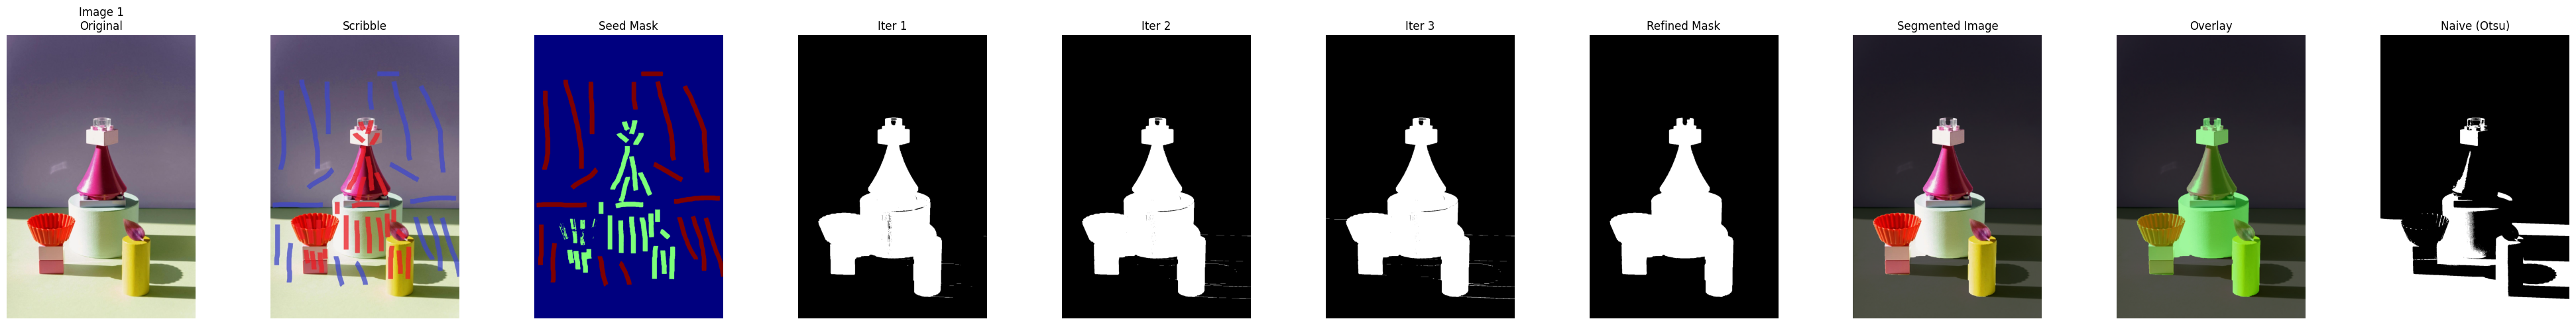

Image 1 processed successfully


Processing Image 2
Image path: /content/cv_a2_data/image4.jpg
Scribble path: /content/cv_a2_data/nature_sc.png
Foreground seed pixels: 57762
Background seed pixels: 45378
  Iteration 1 done
  Iteration 2 done
  Iteration 3 done


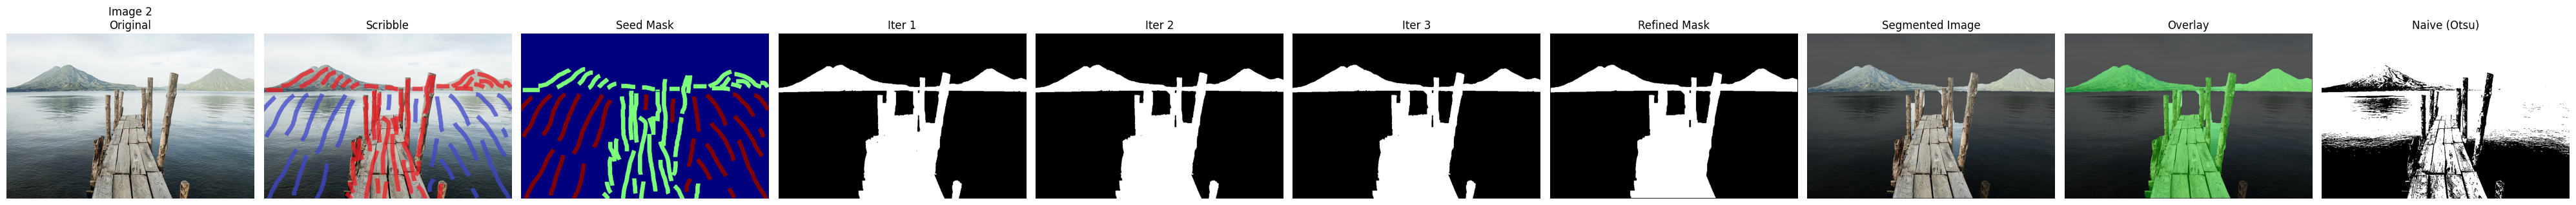

Image 2 processed successfully


Processing Image 3
Image path: /content/cv_a2_data/medical.jpg
Scribble path: /content/cv_a2_data/medical_sc.png
Foreground seed pixels: 5612
Background seed pixels: 25584
  Iteration 1 done
  Iteration 2 done
  Iteration 3 done


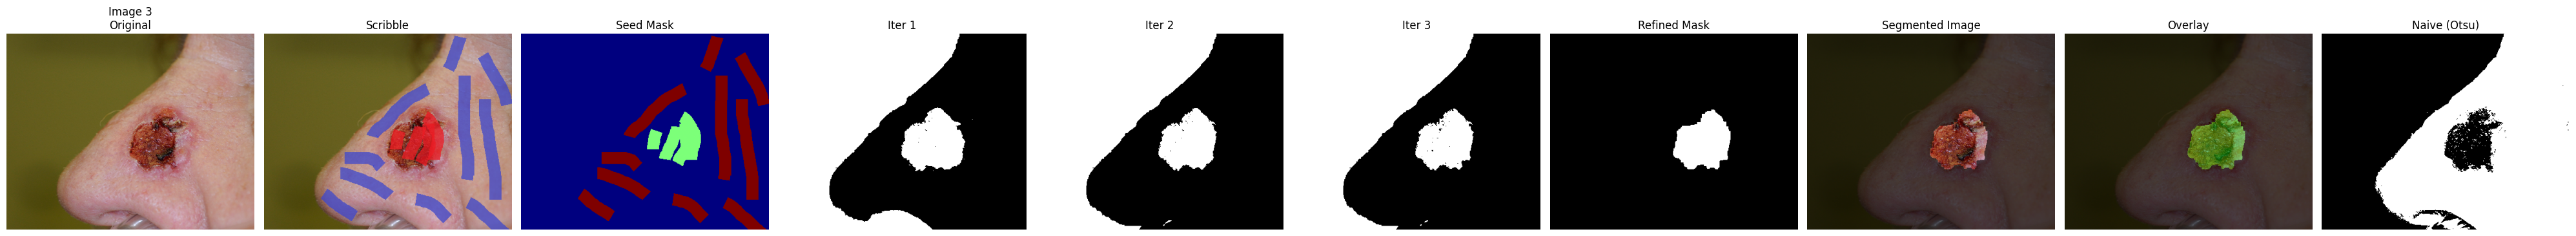

Image 3 processed successfully

Saved output files:
['image4_iter1.png', 'object1_iter1.png', 'medical_overlay.png', 'object1_seedmask.png', 'object1_refined.png', 'object1_iter2.png', 'image4_segmented.png', 'medical_seedmask.png', 'object1_overlay.png', 'image4_seedmask.png', 'image4_naive_otsu.png', 'object1_iter3.png', 'image4_iter2.png', 'medical_iter3.png', 'medical_segmented.png', 'medical_refined.png', 'medical_naive_otsu.png', 'object1_segmented.png', 'image4_refined.png', 'object1_naive_otsu.png', 'image4_iter3.png', 'medical_iter2.png', 'medical_iter1.png', 'image4_overlay.png']


In [111]:
all_results = []

for item in dataset:
    try:
        result = process_one_image(
            item,
            bins=16,
            lam=50,
            num_iters=3,
            save_outputs=True
        )
        all_results.append(result)
        print(f"{item['name']} processed successfully\n")

    except Exception as e:
        print(f"Error while processing {item['name']}: {e}\n")

print("Saved output files:")
print(os.listdir(output_dir))